In [1]:
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math
# os.environ['THEANO_FLAGS'] = "device=cuda0,force_device=True,floatX=float32"
# from aesara_theano_fallback import aesara as theano
#import theano

# print(theano.config.device)
# import sys, getopt
# import tensorflow.keras as keras
# import tensorflow as tf

import matplotlib.pyplot as plt

# from keras.layers import Embedding
# from keras.models import Model
# from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
# from keras.layers.convolutional import Conv1D, MaxPooling1D
# from keras.layers.pooling import GlobalMaxPooling1D
# from keras.layers.recurrent import LSTM
# from keras.layers.wrappers import Bidirectional, TimeDistributed
# from keras.models import load_model
# from keras.callbacks import ModelCheckpoint, EarlyStopping
# from keras import backend as K

In [2]:
def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)

In [51]:
# I/O function
def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

# Normalize an array 
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)

# Given a sequence, return an array of pentamer shape values

def SD_calculation(seq, tb, DNAshape):
    N=10 # calculate SD value for every 10 bps
    shape_values = []

    #Initial the first pentamer
    pentamer = RevOneHotEncode(seq[0:5])
    if pentamer not in tb.keys():
        pentamer = reverse_complement(pentamer)
    for i in range(len(DNAshape)):
        shape_values.append(tb.get(pentamer)[i])

    for i in range(1, len(seq)-5):
        pentamer = RevOneHotEncode(seq[i:i+5])
        if pentamer not in tb.keys():
            pentamer = reverse_complement(pentamer)
        else:
            for j in range(0, len(DNAshape)):
                shape_values[j] = shape_values[j] + tb.get(pentamer)[j]
    return shape_values;

def nucseq_shape_analysis(fname, out, DNAshape, tb):

    # Open and read file
    if os.path.isfile(fname):
        mat_contents = sio.loadmat(fname)
        edata=mat_contents['EnrichedData']
        ddata=mat_contents['DepletedData']
#     print(tb)

    shapes = []
    np_allEnrichSeqArr = np.array(edata)
    np_allDepleteSeqArr = np.array(ddata)
    print(f"3 np_allEnrichSeqArr.shape {np_allEnrichSeqArr.shape}, np_allDepleteSeqArr.shape {np_allDepleteSeqArr.shape}");
    for d in ddata:
        if 'N' not in d:
            shape_values = SD_calculation(d, tb, DNAshape)
            shapes.append(shape_values)

    string = ""
    for line in shapes:
        curr_str = " ".join(str(s) for s in line)
        string = string + curr_str + "\n"
    
    f = open(out, 'w+');
    f.write(string)
    f.write("\n")
    f.close()
    
## Get the values of all shapes from tb to a normalized array and an array
def shape_param_analysis(tb):

    all_shape_vals = []
    for pentamer in tb.keys():
        shape_vals = tb[pentamer]
        all_shape_vals+= [shape_vals]
    all_shape_vals2 = np.array(all_shape_vals).T
    all_norm_shape_vals = []
    
    # Perform per-shape normalization
    for shape in all_shape_vals2:
        all_norm_shape_vals+= [min_max_norm(shape)]
    return all_norm_shape_vals, all_shape_vals2;

AllDNAshape =['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

# fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
# fileName = "/home/yibei/Projects/nucleosome_occupancy/mc_pentamer_06042020.txt"
fileName = "/Users/yibeijia/Downloads/ProjectStuff/pentamer_table.txt"
tb = read_SD_table(fileName);

In [52]:


#################################### GC color group
def CGColor(tb):
    color_group = []
    debug = 0
    for pentamer in tb.keys():
        GC = 0
        for letter in pentamer:
            if letter == 'C' or letter == 'G' : 
                GC+=1

        color_group += [GC]
        debug += 1
    return color_group

#################################### A track color group
def AColor(tb):
    color_group = []
    debug = 0

    for pentamer in tb.keys():
#         if debug < 10:
#         print(pentamer)
        curr_seq = ''
        longest = ''
        for letter in pentamer:
            # Since we are tracking Atract, change all Ts to A to facilitate count because of reverse complement
            if letter == 'T':
                letter = 'A'
            if letter == 'G':
                letter = 'C'    
            if len(curr_seq) == 0: 
                curr_seq = letter
            else:
                # if the next letter to append is different
                if curr_seq[-1] != letter:
                    if len(curr_seq) > len(longest):
                        longest = curr_seq # Update the longest seq
                    curr_seq = letter # start the track over

                # if the next letter to append is the same
                else:
                    curr_seq += letter #continue append

                    # if we reach 5 letter, report it as the longest seq now
                    if len(curr_seq) == 5:
                        longest = curr_seq
        color_group += [longest]
#         debug += 1
#     print(color_group)
    cols = []
    for seq in color_group:
        if 'A' in seq:
            cols.append(len(seq)) 
        if 'C' in seq:
            cols.append(5+len(seq))
    return cols

def AtrackCalc(seq):
    color_group = []
    longest=''
#     curr_seq=''
    AllAtracks=[]
    start=0
    end=0
    count=0
    for letter in seq[1:]:
        count+=1
#         print(">>>>>>>>>>>>>")
#         print(f"current pos: {count}")
#         print(f"current letter: {letter}")        
#         print(f"last letter: {seq[count-1]}")        

        if seq[count-1] != letter: #If not equal, check sequence
            if seq[count-1]=='A' and letter=='T': #only ApT doesn't breaks Atrack\
#                 print("***ApT")
                end+=1
            elif seq[count-1]=='C' and letter=='G':
                end+=1
            elif seq[count-1]=='G' and letter=='C':
                end+=1            
            else:
#                 print("A track broken")
#                 print(f"Appednign start:{start}, end:{end+1}")
                AllAtracks.append(seq[start:end+1])
                start=count
                end=count
        else: #If equal, expand sequence
#             print("equal, expand seq")
            end+=1
#         print(f"end: {end}")
        if end == len(seq)-1:
            AllAtracks.append(seq[start:end+1])
    for atrack in AllAtracks:
        if len(atrack) > len(longest):
            longest=atrack
    #             longest = seq[start:end]
    return longest,AllAtracks


def tbAtrackColor(tb):
    tbAtrackColors=[]
    for seq in tb.keys():
        longest,AllAtracks=AtrackCalc(seq)
    #     print(AllAtracks)
#         print(longest)
        if 'A' in longest or 'T' in longest:
            tbAtrackColors.append(len(longest))
        else:
            tbAtrackColors.append(len(longest)+5)
    return tbAtrackColors

def tbAtrackColorNoCG(tb):
    tbAtrackColors=[]
    for seq in tb.keys():
        longest,AllAtracks=AtrackCalc(seq)
    #     print(AllAtracks)
#         print(longest)
        if 'A' in longest or 'T' in longest:
            tbAtrackColors.append(len(longest))
        else:
            curr_longest = 0
            for kmer in AllAtracks:
                if 'A' in kmer or 'T' in kmer:
                    if len(kmer) > curr_longest:
                        curr_longest = len(kmer)
            tbAtrackColors.append(curr_longest)
    return tbAtrackColors

In [32]:
CGColor(tb)

[2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 1,
 4,
 0,
 3,
 2,
 3,
 2,
 4,
 3,
 4,
 1,
 3,
 4,
 3,
 1,
 2,
 4,
 5,
 4,
 1,
 3,
 4,
 3,
 0,
 2,
 3,
 1,
 3,
 3,
 3,
 2,
 1,
 4,
 0,
 3,
 2,
 3,
 1,
 4,
 1,
 2,
 1,
 3,
 1,
 4,
 5,
 2,
 2,
 3,
 1,
 2,
 2,
 2,
 1,
 1,
 3,
 3,
 2,
 3,
 3,
 2,
 4,
 2,
 3,
 1,
 3,
 4,
 4,
 3,
 2,
 4,
 2,
 4,
 2,
 4,
 3,
 3,
 1,
 3,
 3,
 4,
 1,
 1,
 1,
 4,
 4,
 4,
 1,
 3,
 1,
 4,
 2,
 3,
 3,
 4,
 3,
 2,
 2,
 1,
 1,
 3,
 2,
 1,
 3,
 5,
 3,
 5,
 3,
 3,
 2,
 3,
 3,
 1,
 2,
 2,
 3,
 5,
 3,
 4,
 1,
 3,
 4,
 4,
 2,
 3,
 1,
 2,
 5,
 3,
 3,
 2,
 3,
 4,
 2,
 1,
 1,
 2,
 4,
 2,
 2,
 4,
 3,
 3,
 1,
 3,
 2,
 2,
 4,
 3,
 3,
 3,
 1,
 4,
 2,
 0,
 2,
 3,
 1,
 1,
 2,
 3,
 4,
 1,
 4,
 3,
 3,
 3,
 4,
 2,
 2,
 3,
 2,
 1,
 3,
 3,
 4,
 3,
 2,
 5,
 2,
 4,
 3,
 4,
 4,
 3,
 3,
 3,
 4,
 2,
 4,
 2,
 4,
 2,
 2,
 4,
 4,
 2,
 2,
 1,
 2,
 4,
 1,
 2,
 1,
 1,
 3,
 2,
 3,
 2,
 2,
 3,
 1,
 1,
 2,
 1,
 3,
 4,
 2,
 4,
 1,
 0,
 2,
 2,
 3,
 3,
 2,
 2,
 2,
 3,
 2,
 1,
 4,
 3,
 3,
 2,
 2,
 2,
 2,
 2,
 1,


In [53]:
longest,AllAtracks=AtrackCalc('ACCCC')
print(AllAtracks)
print(longest)
tbAtrackColors=tbAtrackColorNoCG(tb)
for i in range(len(tbAtrackColors)):
    print(f'{tbAtrackColors[i]}    {list(tb.keys())[i]}')

['A', 'CCCC']
CCCC
3    CAAAC
2    ACCTT
3    CATTG
1    GTACG
2    CAAGG
1    TCACC
1    GCTCA
1    CGAGT
1    GGTGA
1    TCGAC
2    ATACA
1    GCCGT
2    ATATA
1    CACGA
2    GAACA
1    CACAG
2    TGATC
1    GGTCG
1    CGTGA
1    GGTGG
2    ACTAT
1    CCAGT
1    GGCAG
1    CCAGA
3    AATCA
1    TACGT
1    TGCGG
0    CCCGC
1    TCGGG
2    TATCT
1    CGTAC
1    CCTGG
2    CGCAT
4    TTTTA
1    ACAGT
1    GCTGA
3    TGATT
1    TACGG
2    AAGGG
2    GCGAT
1    TACCA
3    AGAAA
1    CTCCC
3    ATTAT
1    GCCTA
2    CACAT
1    GTCGA
3    TATTC
1    TCGCC
3    TGAAT
3    TTTGG
2    CTATA
2    CGATG
2    TACAT
1    AGCGC
0    GCCCG
2    GATAC
2    GTTCA
1    GTCCA
3    CTATT
3    TTTCG
2    GACTT
1    TCACT
3    AAACT
4    AAAAG
1    AGTGG
2    CGCAA
2    CTGAT
1    GTGAG
1    AGGCA
2    AGATC
1    CAGGG
3    CTTTG
1    GAGGT
3    GTATT
1    ACGTG
1    GGTCC
1    GGAGC
2    GGTTC
3    CCAAA
1    AGGGC
2    ATACC
1    CGGGT
2    GGTAA
1    GCGCA
1    AGGGT
1    CAGAC
3    AAAGT
1    CGCTA
1 

In [54]:
########################## DNA Shape Values Distribution ##########################
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

# Get the location of each shape in the table

intra_trans = list(range(0,3))
intra_rot = list(range(3,6))
inter_trans = list(range(6,12))
inter_rot = list(range(12,18))

GrooveWidth = list(range(18,22))
intra_trans_SD = list(range(22,25))
intra_rot_SD = list(range(25,28))
inter_trans_SD = list(range(28,31))
inter_rot_SD=  list(range(31,34))
GrooveWidth_SD = list(range(34,37))

All_params = [intra_trans, intra_rot,inter_trans,inter_rot,GrooveWidth,intra_trans_SD,inter_trans_SD,intra_rot_SD,inter_rot_SD,GrooveWidth_SD]

# print(All_params)   

all_norm_shape_vals, all_shape_vals = shape_param_analysis(tb)
trans = np.array(all_norm_shape_vals).T
df = pd.DataFrame(trans, columns = AllDNAshape)
df['Pentamer'] = tb.keys()     
##### Add Atract length

df['Atract'] = tbAtrackColor(tb)
df['AtractNoCG'] = tbAtrackColorNoCG(tb)

print(df)

         Shear   Stretch   Stagger    Buckle      ProT   Opening       MGW  \
0     0.724992  0.292479  0.460170  0.823914  0.148779  0.074200  0.593756   
1     0.929417  0.419220  0.875870  0.344026  0.902775  0.862020  0.249212   
2     0.274229  0.328691  0.540797  0.369185  0.338463  0.250705  0.529323   
3     0.677781  0.279944  0.734725  0.610271  0.426720  0.432083  0.933702   
4     0.712527  0.448468  0.710557  0.803725  0.405047  0.377743  0.546042   
...        ...       ...       ...       ...       ...       ...       ...   
1019  0.099875  0.423398  0.448376  0.193808  0.360542  0.960984  0.511382   
1020  0.748052  0.692201  0.784029  0.977747  0.194704  0.505854  0.338113   
1021  0.055002  0.122563  0.647912  0.465064  0.585645  0.777063  0.767603   
1022  0.062792  0.282730  0.741493  0.575372  0.745742  0.824874  0.777892   
1023  0.886881  0.151811  0.618910  0.586598  0.689494  0.801796  0.653656   

            EP  Shear-FL  Stretch-FL  ...  Rise-FL_1  Tilt-FL_-

In [7]:
def getLongestKmer(pentamer):
    longest = ''
    start =0
    end =0
    conseq_letter = ''
    count = 0
    for curr_letter in pentamer:
        print("-------------------------")
        count+=1
        print(f"conseq letter is {conseq_letter}")
        if curr_letter == conseq_letter:
            print("same letter")
            longest+=curr_letter
            end +=1
        else:
            print("not same letter")
            print(f"(end - start) is {(end - start)}")
            if (end - start) > len(longest):
                longest = ''
                start = count
            print(f"longest letter is {longest}")
            conseq_letter = curr_letter
    return longest

In [8]:
getLongestKmer('TAAAA')

-------------------------
conseq letter is 
not same letter
(end - start) is 0
longest letter is 
-------------------------
conseq letter is T
not same letter
(end - start) is 0
longest letter is 
-------------------------
conseq letter is A
same letter
-------------------------
conseq letter is A
same letter
-------------------------
conseq letter is A
same letter


'AAA'

In [55]:
import collections
tb_ordered = collections.OrderedDict(sorted(tb.items()))
# print(tb_ordered['AAAAA'])
# print(all_shape_vals2[0])
# # print(all_norm_shape_vals[0])
# tb_norm={}
# for i in range(len(tb_ordered.keys())):
#     tb_norm[tb_ordered.keys()[i]]=all_norm_shape_vals[i]
# tb_norm
tb_ordered

OrderedDict([('AAAAA',
              [0.1585,
               -0.0098,
               -0.0836,
               8.002,
               -14.9156,
               -2.0769,
               3.8846,
               -10.6188,
               0.2544,
               0.1209,
               0.3444,
               8.1741,
               7.1416,
               4.7619,
               1.3501,
               -0.0859,
               -0.0859,
               -1.0338,
               -1.0338,
               3.2774,
               3.2774,
               -0.9298,
               -0.9298,
               -4.685,
               -4.685,
               37.6927,
               37.6927,
               0.5549,
               0.5549,
               0.446,
               0.446,
               0.2934,
               0.2934,
               3.3414,
               3.3414,
               5.8623,
               5.8623,
               3.9465,
               3.9465]),
             ('AAAAC',
              [0.1494,
               -0.01

<ipython-input-69-388d530d2b91>:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.ax.set_yticklabels(['(A/T)*5', '(A/T)*4', '(A/T)*3', '(A/T)*2', '(A/T)*1','(C/G)*1','(C/G)*2','(C/G)*3','(C/G)*4','(C/G)*5'])


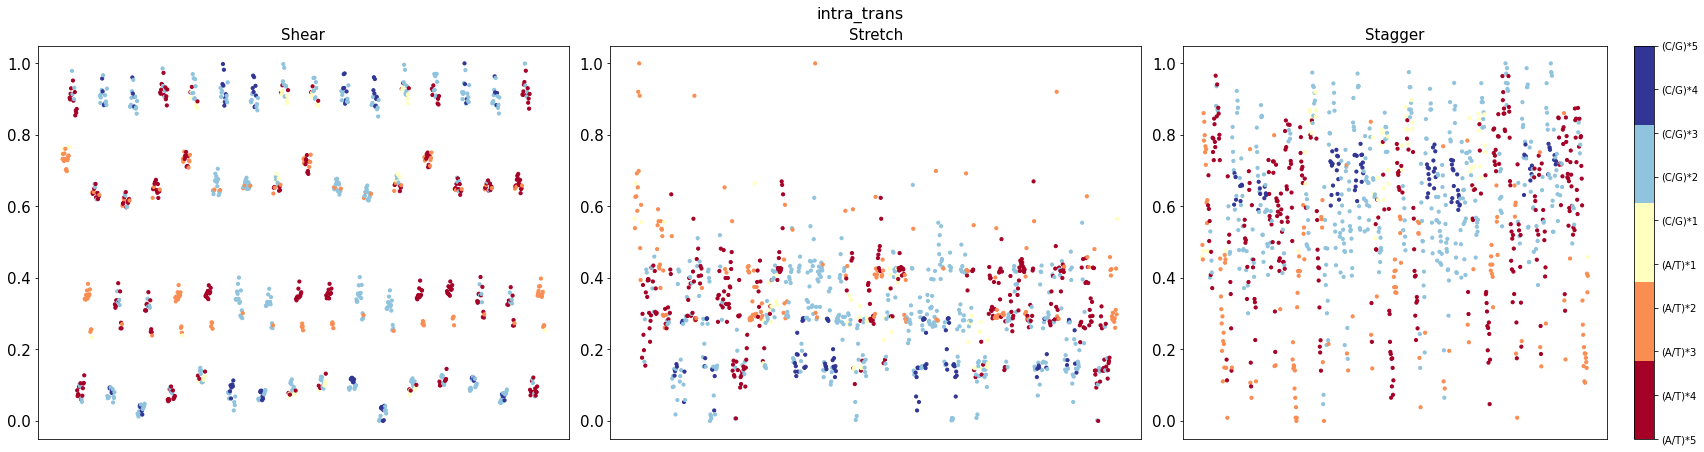

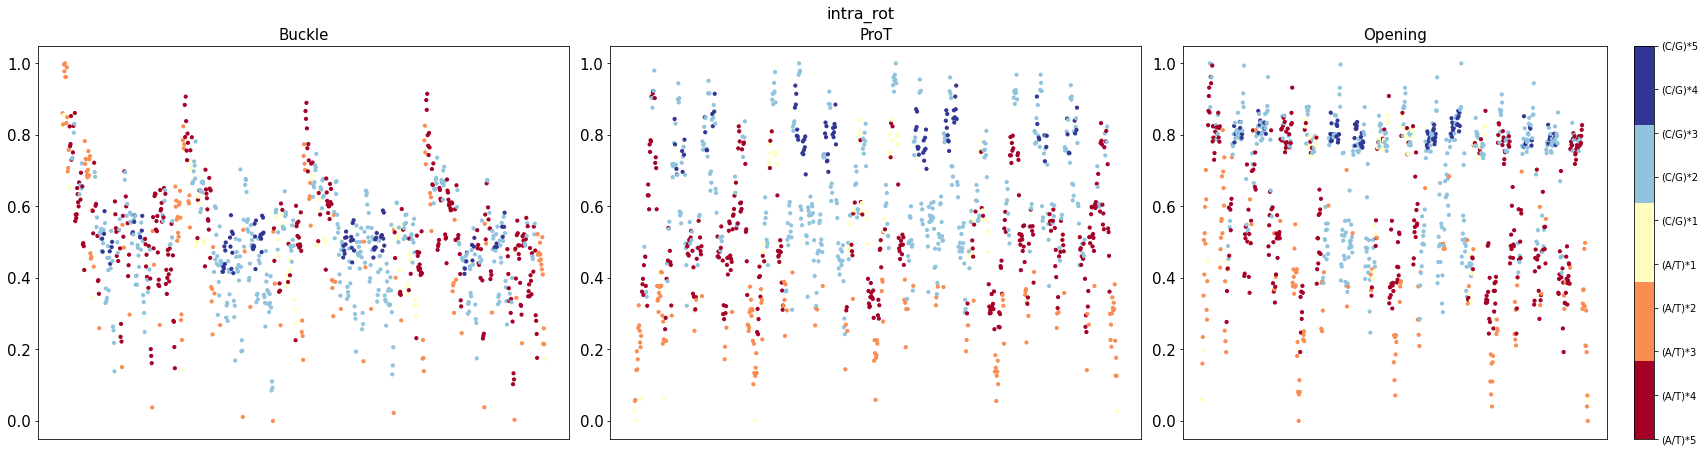

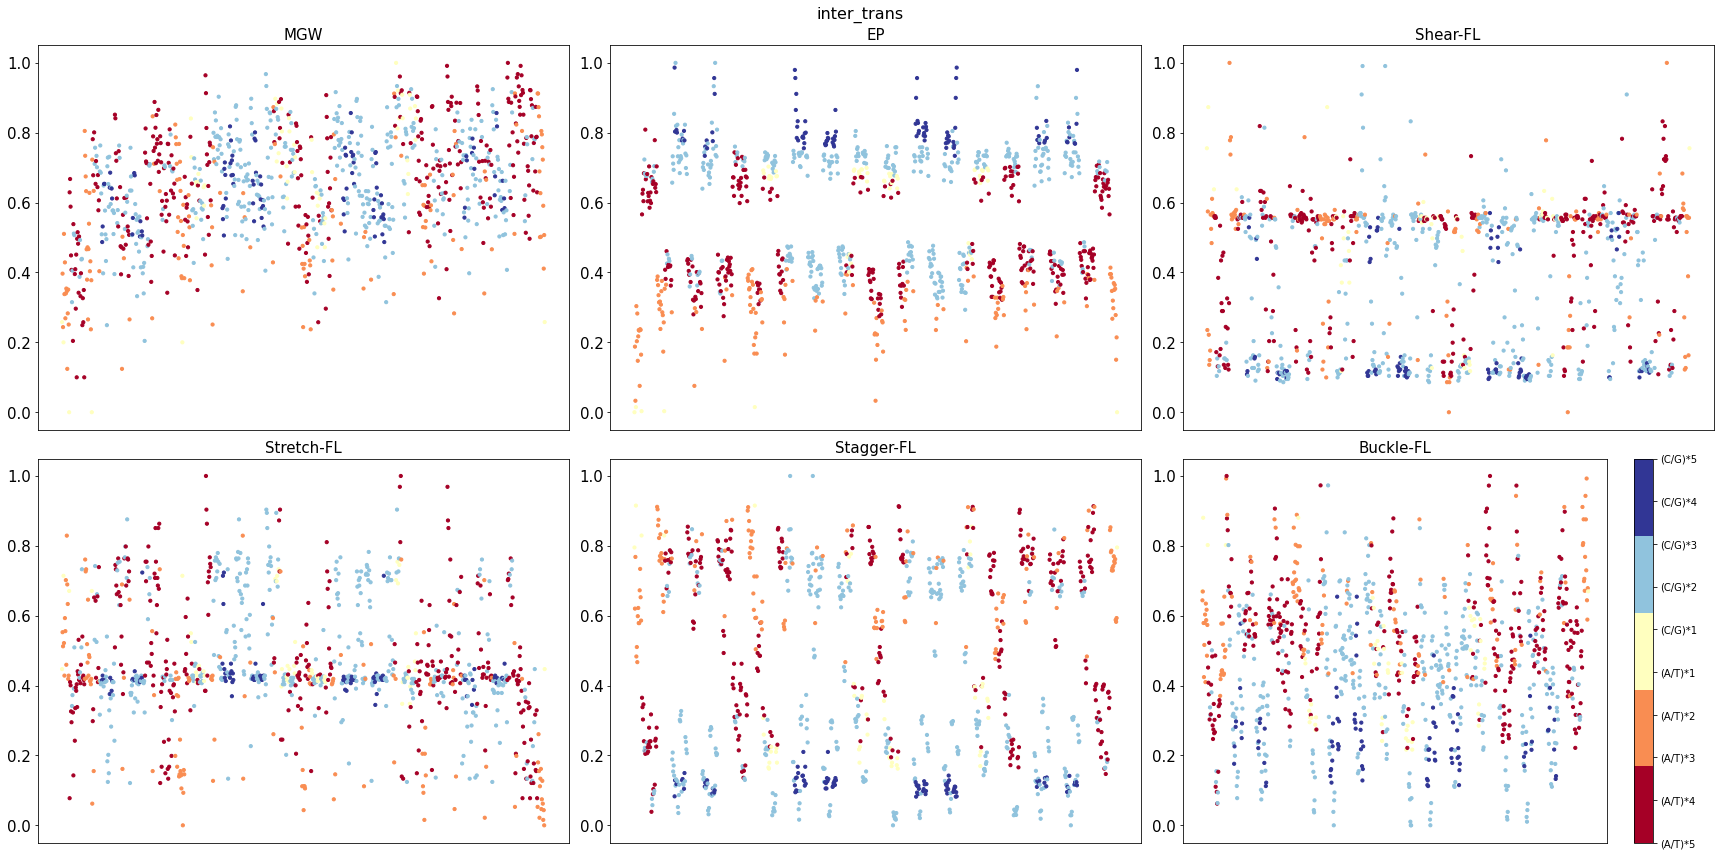

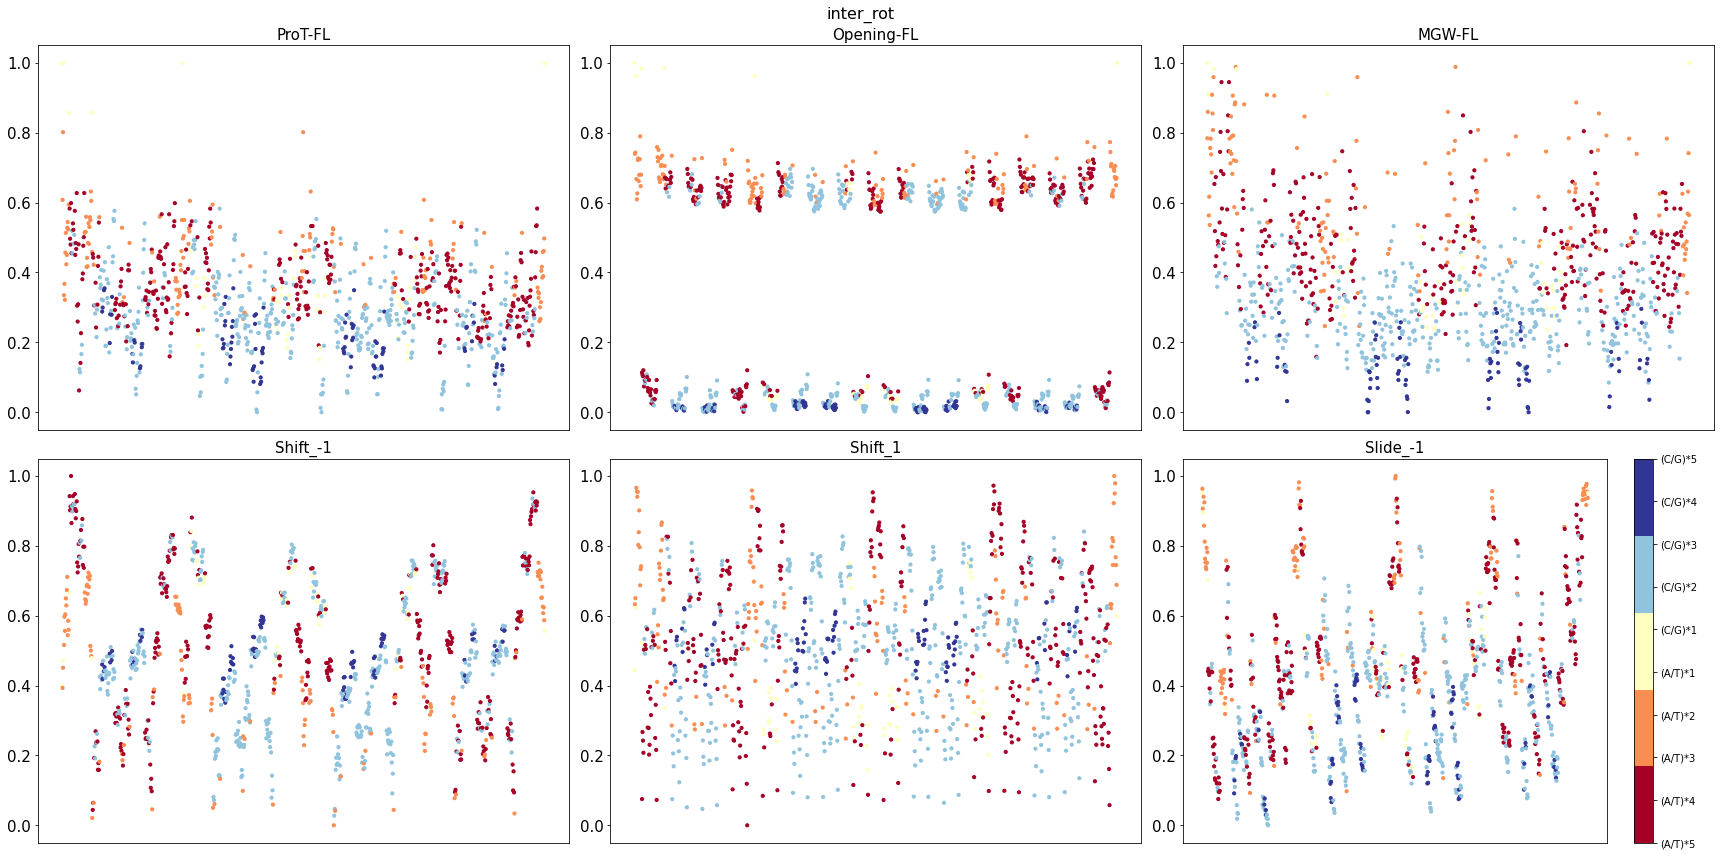

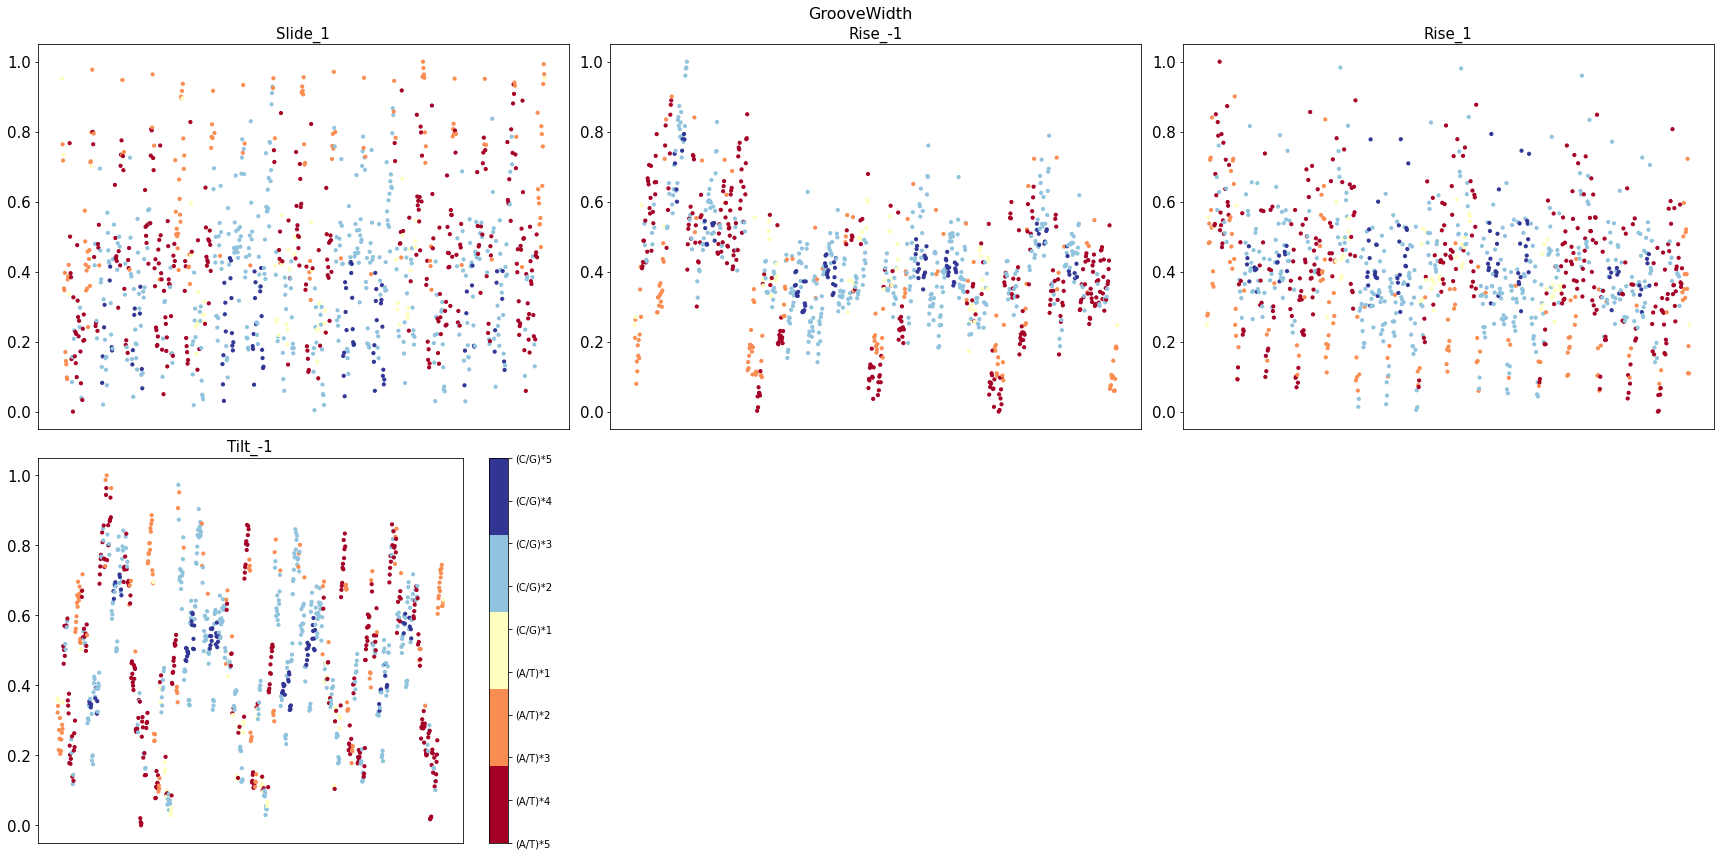

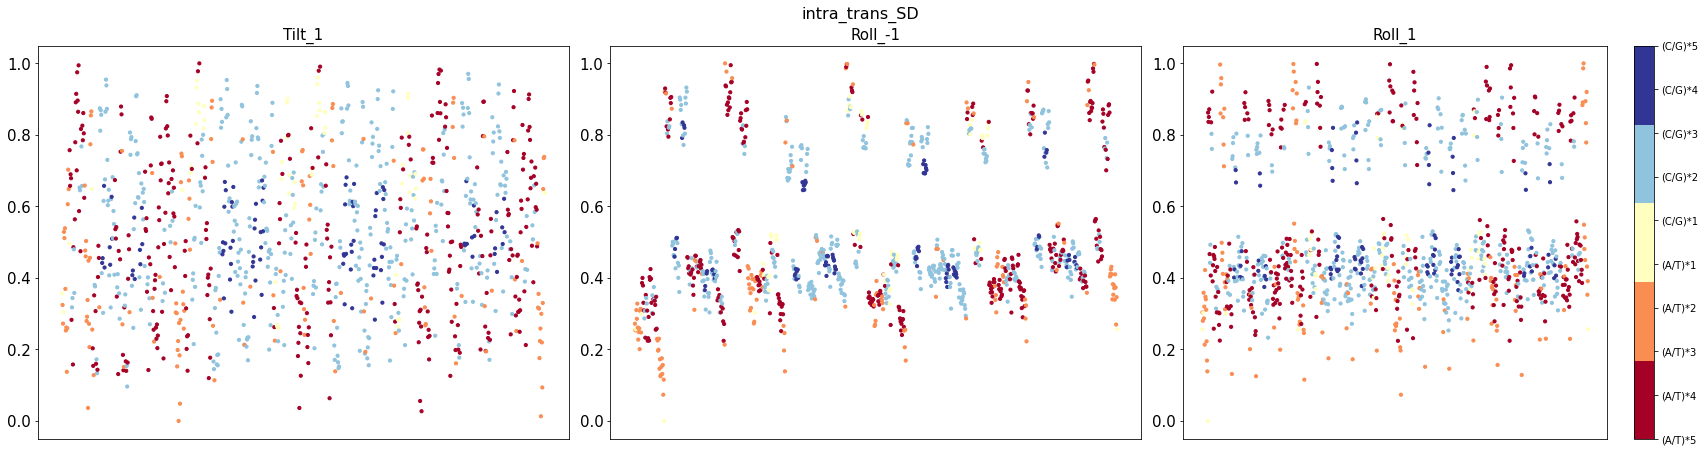

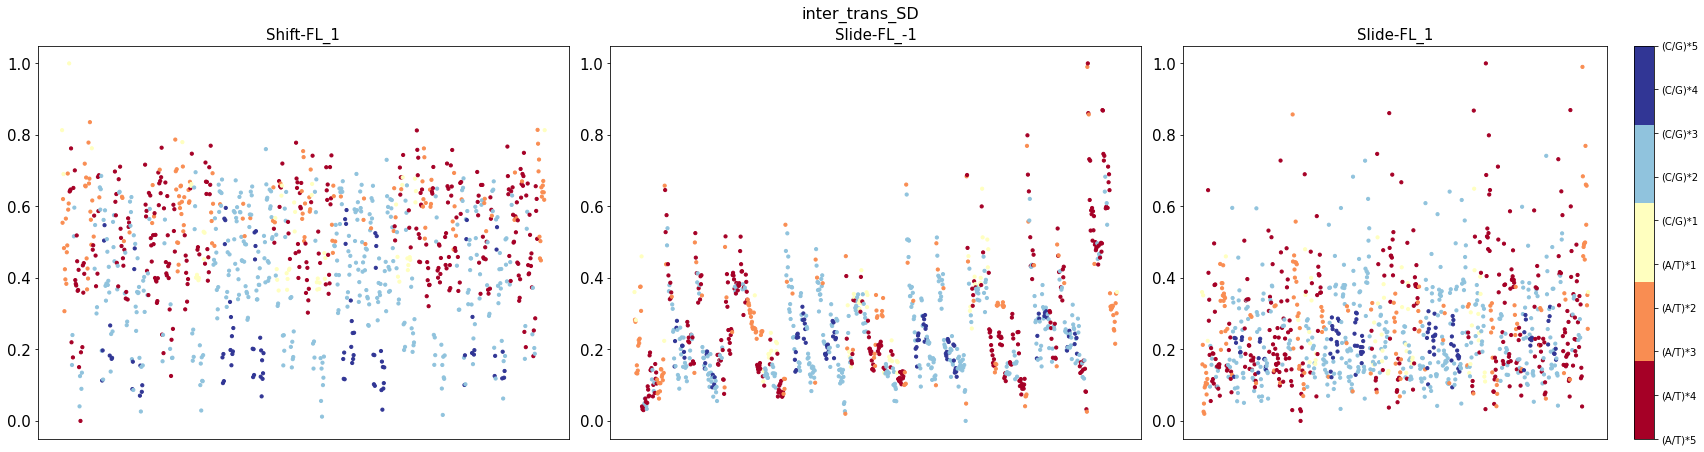

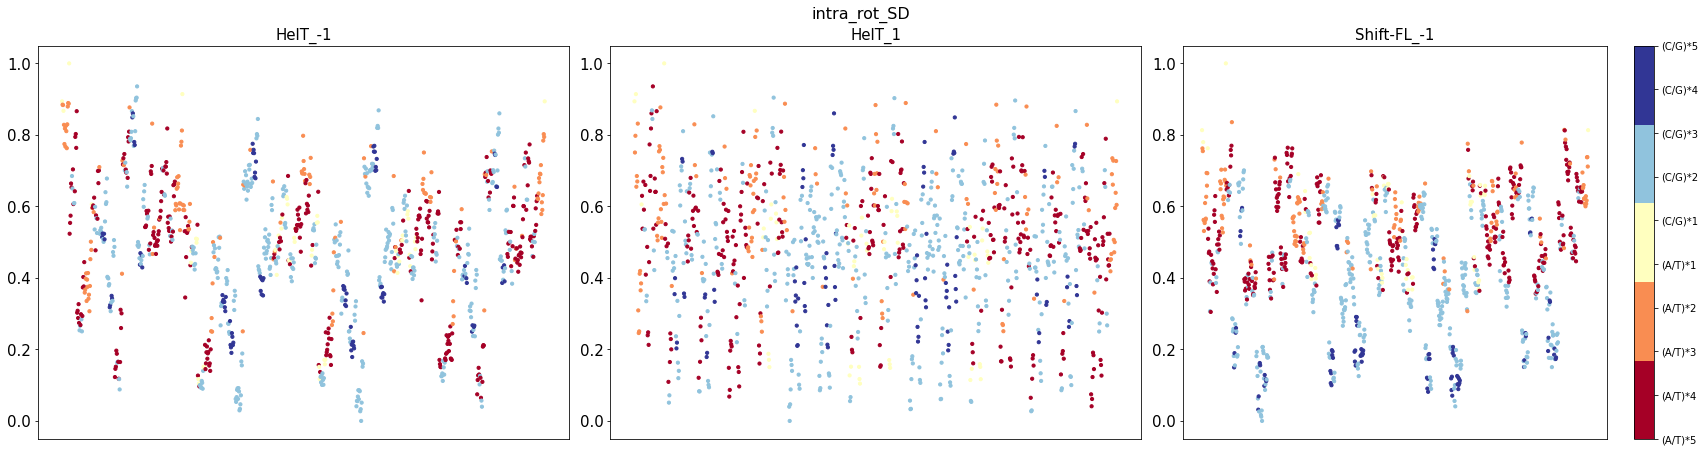

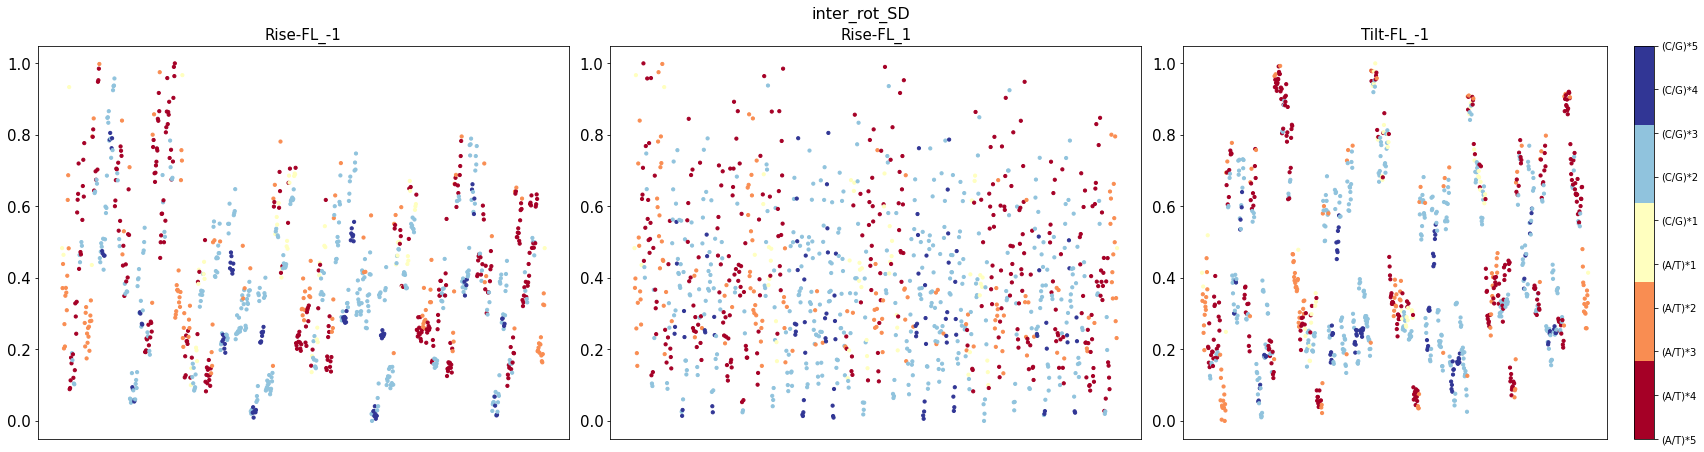

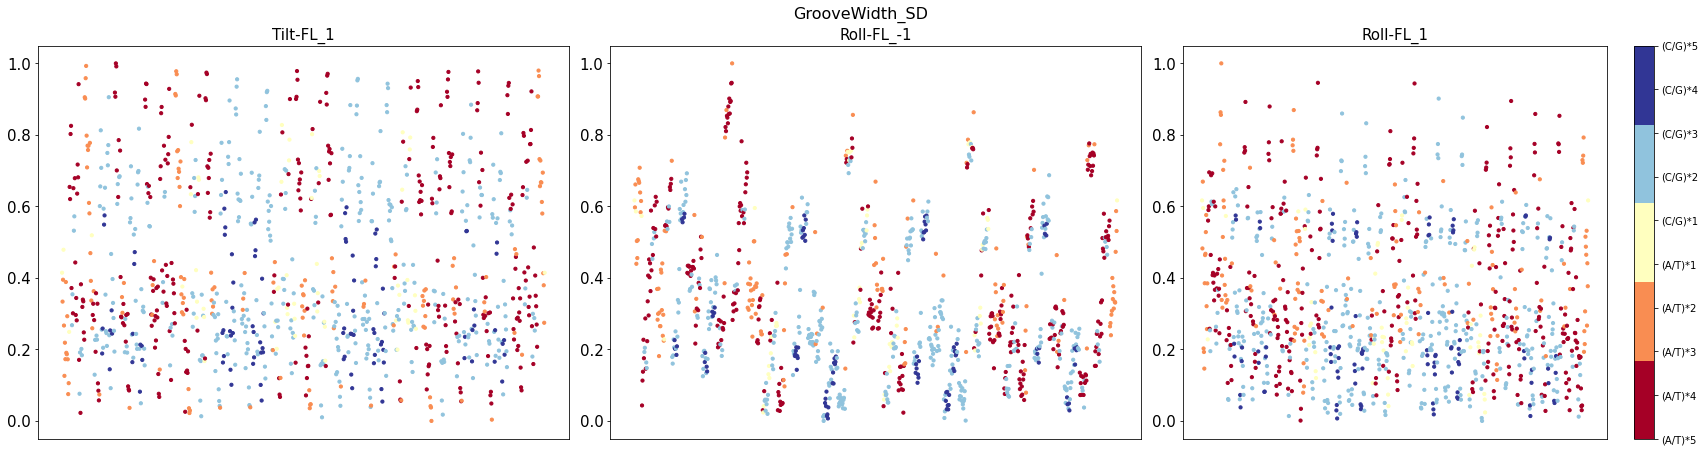

In [69]:
#################################### DNA Shape values ####################################
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.spines 
from matplotlib.ticker import PercentFormatter
import  matplotlib.cm as cm
all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb_ordered)


for i in range(len(All_params)):
# for i in range(2):
    pic_index = All_params[i]
    fig = plt.figure(figsize=(24,12))
    fig.suptitle(All_params_names[i], fontsize=16)
    total_plot_num = len(pic_index)
#     for j in range(2):
    for j in range(len(pic_index)):

        # Set up the plot
        ax = plt.subplot(2, 3, j+1)
    
        # Draw the plot
        x = all_norm_shape_vals[pic_index[j]]
        
        ############ Atrack plot
        cols = tbAtrackColor(tb_ordered)
        plt.scatter(tb_ordered.keys(), x, s=10, c=cols, cmap=cm.get_cmap('RdYlBu', 5))
        
        plt.tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False) # labels along the bottom edge are off
        plt.tick_params(
            axis='y',          # changes apply to the x-axis
            labelsize=15) # labels along the bottom edge are off
#         Title and labels
        ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 15)
#         ax.axvline(x='AAAAA', color='grey')
#         ax.axvline(x='CAAAA', color='grey')
#         ax.axvline(x='GAAAA', color='grey')
#         ax.axvline(x='TAAAA', color='grey')
#         [i.set_linewidth(1.5) for i in ax.spines.values()]
        
    plt.tight_layout()
    cbar = plt.colorbar()
#     cbar = fig.colorbar(ticks=range(1,1))
    ############ AT option
    cbar.ax.set_yticklabels(['(A/T)*5', '(A/T)*4', '(A/T)*3', '(A/T)*2', '(A/T)*1','(C/G)*1','(C/G)*2','(C/G)*3','(C/G)*4','(C/G)*5']) 

    ############ CG option
    plt.savefig(All_params_names[i]+"_scatter.jpg")
    plt.show()

In [57]:
AllDNAshape =['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']

index = AllDNAshape.index('ProT-FL')
index
all_shape_vals2[index]

array([5.985 , 5.8567, 6.1409, ..., 5.7393, 5.4419, 5.8028])

In [69]:
len(tb.keys())

1024

In [58]:
import pandas as pd
import collections
tb_ordered=collections.OrderedDict(sorted(tb.items()))
tb_df = pd.DataFrame.from_dict(tb_ordered, orient='index',columns=AllDNAshape)
tb_df

,Shear,Stretch,Stagger,Buckle,ProT,Opening,MGW,EP,Shear-FL,Stretch-FL,...,Slide-FL_-1,Slide-FL_1,Rise-FL_-1,Rise-FL_1,Tilt-FL_-1,Tilt-FL_1,Roll-FL_-1,Roll-FL_1,HelT-FL_-1,HelT-FL_1
AAAAA,0.1585,-0.0098,-0.0836,8.0020,-14.9156,-2.0769,3.8846,-10.6188,0.2544,0.1209,...,0.4460,0.4460,0.2934,0.2934,3.3414,3.3414,5.8623,5.8623,3.9465,3.9465
AAAAC,0.1494,-0.0117,-0.0663,8.8585,-14.4945,-1.7474,4.3160,-9.0660,0.2429,0.1243,...,0.4232,0.3864,0.2730,0.2731,3.2554,3.2532,5.8076,5.4856,3.8645,3.7156
AAAAG,0.1582,-0.0054,-0.0874,8.0892,-14.4479,-1.5057,3.8397,-10.3464,0.2504,0.1230,...,0.4215,0.4025,0.2853,0.2779,3.2756,3.3200,5.9875,6.0097,3.8673,3.7298
AAAAT,0.1675,-0.0027,-0.0752,8.7426,-15.3464,-1.6260,3.7040,-10.4979,0.2570,0.1295,...,0.4229,0.4433,0.2900,0.3817,3.2992,3.4116,5.7760,5.8028,3.8369,3.9573
AAACA,0.1457,-0.0053,0.1243,12.2045,-13.1763,-1.1268,4.6698,-8.1077,0.2426,0.1233,...,0.3792,0.3474,0.2422,0.2524,3.1577,3.1801,5.3653,4.7009,3.6955,3.4661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGT,-0.0892,-0.0317,-0.2442,-2.2202,-11.9197,-1.6432,5.3309,-7.6962,0.2500,0.1085,...,0.4034,0.5337,0.2393,0.3504,3.1717,3.6471,5.0609,5.6246,3.8280,4.0518
TTTTA,-0.1523,-0.0281,-0.1079,-6.9864,-13.4145,-2.1393,4.9203,-8.3192,0.2463,0.1070,...,0.4368,0.4351,0.2646,0.2561,3.2870,3.3399,5.4591,4.8805,3.9224,3.8776
TTTTC,-0.1497,-0.0198,-0.1349,-5.9280,-12.6478,-2.0386,4.3607,-9.3758,0.2413,0.1079,...,0.4447,0.4436,0.2703,0.2679,3.2725,3.3030,5.7786,5.3692,3.9378,3.8949
TTTTG,-0.1493,-0.0290,-0.1110,-7.0184,-13.4225,-2.2708,4.6594,-8.8477,0.2500,0.1065,...,0.4285,0.4157,0.2643,0.2475,3.2488,3.1885,5.6225,5.1891,3.9373,3.8573


In [61]:
labels = []
tbAtrackColors_ordered=tbAtrackColor(tb_ordered)

Atrack_length=tbAtrackColors_ordered
for i in Atrack_length:
    if i ==5:
        labels.append('(A/T)*5')
    elif i ==4:
        labels.append('(A/T)*4')
    elif i ==3:
        labels.append('(A/T)*3')
    elif i ==2:
        labels.append('(A/T)*2')
    elif i ==1:
        labels.append('(A/T)*1')
    elif i ==6:
        labels.append('(C/G)*1')
    elif i ==7:
        labels.append('(C/G)*2')
    elif i ==8:
        labels.append('(C/G)*3')
    elif i ==9:
        labels.append('(C/G)*4')
    elif i ==10:
        labels.append('(C/G)*5')

# for i in Atrack_length:
#     if i ==5:
#         labels.append('(A/T)*5')
#     elif i ==4:
#         labels.append('(A/T)*4')
#     elif i ==3:
#         labels.append('(A/T)*3')
#     elif i ==2:
#         labels.append('(A/T)*2')
#     elif i ==1:
#         labels.append('(A/T)*1')
#     elif i ==0:
#         labels.append('(A/T)*0')

# print(Atrack_length)
# print(labels)
tb_df['AtrackLength']=labels
tb_df

,Shear,Stretch,Stagger,Buckle,ProT,Opening,MGW,EP,Shear-FL,Stretch-FL,...,Slide-FL_1,Rise-FL_-1,Rise-FL_1,Tilt-FL_-1,Tilt-FL_1,Roll-FL_-1,Roll-FL_1,HelT-FL_-1,HelT-FL_1,AtrackLength
AAAAA,0.1585,-0.0098,-0.0836,8.0020,-14.9156,-2.0769,3.8846,-10.6188,0.2544,0.1209,...,0.4460,0.2934,0.2934,3.3414,3.3414,5.8623,5.8623,3.9465,3.9465,(A/T)*5
AAAAC,0.1494,-0.0117,-0.0663,8.8585,-14.4945,-1.7474,4.3160,-9.0660,0.2429,0.1243,...,0.3864,0.2730,0.2731,3.2554,3.2532,5.8076,5.4856,3.8645,3.7156,(A/T)*4
AAAAG,0.1582,-0.0054,-0.0874,8.0892,-14.4479,-1.5057,3.8397,-10.3464,0.2504,0.1230,...,0.4025,0.2853,0.2779,3.2756,3.3200,5.9875,6.0097,3.8673,3.7298,(A/T)*4
AAAAT,0.1675,-0.0027,-0.0752,8.7426,-15.3464,-1.6260,3.7040,-10.4979,0.2570,0.1295,...,0.4433,0.2900,0.3817,3.2992,3.4116,5.7760,5.8028,3.8369,3.9573,(A/T)*5
AAACA,0.1457,-0.0053,0.1243,12.2045,-13.1763,-1.1268,4.6698,-8.1077,0.2426,0.1233,...,0.3474,0.2422,0.2524,3.1577,3.1801,5.3653,4.7009,3.6955,3.4661,(A/T)*3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGT,-0.0892,-0.0317,-0.2442,-2.2202,-11.9197,-1.6432,5.3309,-7.6962,0.2500,0.1085,...,0.5337,0.2393,0.3504,3.1717,3.6471,5.0609,5.6246,3.8280,4.0518,(A/T)*3
TTTTA,-0.1523,-0.0281,-0.1079,-6.9864,-13.4145,-2.1393,4.9203,-8.3192,0.2463,0.1070,...,0.4351,0.2646,0.2561,3.2870,3.3399,5.4591,4.8805,3.9224,3.8776,(A/T)*4
TTTTC,-0.1497,-0.0198,-0.1349,-5.9280,-12.6478,-2.0386,4.3607,-9.3758,0.2413,0.1079,...,0.4436,0.2703,0.2679,3.2725,3.3030,5.7786,5.3692,3.9378,3.8949,(A/T)*4
TTTTG,-0.1493,-0.0290,-0.1110,-7.0184,-13.4225,-2.2708,4.6594,-8.8477,0.2500,0.1065,...,0.4157,0.2643,0.2475,3.2488,3.1885,5.6225,5.1891,3.9373,3.8573,(A/T)*4


In [63]:
def normalize(df):
    result = df.copy()
    for feature_name in df.columns:
        if feature_name != 'AtrackLength':
            max_value = df[feature_name].max()
            min_value = df[feature_name].min()
            result[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
        else:
            result[feature_name]=df[feature_name]
    return result

In [64]:
norm_tb_df = normalize(tb_df)
norm_tb_df

,Shear,Stretch,Stagger,Buckle,ProT,Opening,MGW,EP,Shear-FL,Stretch-FL,...,Slide-FL_1,Rise-FL_-1,Rise-FL_1,Tilt-FL_-1,Tilt-FL_1,Roll-FL_-1,Roll-FL_1,HelT-FL_-1,HelT-FL_1,AtrackLength
AAAAA,0.746962,0.565460,0.458817,0.825714,0.028199,0.059427,0.258054,0.000000,0.755656,0.447205,...,0.360366,0.483288,0.483288,0.414522,0.414522,0.616706,0.616706,0.609329,0.609329,(A/T)*5
AAAAC,0.732783,0.538997,0.492266,0.860577,0.055764,0.160414,0.396759,0.187781,0.235294,0.552795,...,0.158127,0.371507,0.372055,0.335775,0.333761,0.597205,0.482406,0.543723,0.424594,(A/T)*4
AAAAG,0.746494,0.626741,0.451469,0.829263,0.058814,0.234492,0.243618,0.032942,0.574661,0.512422,...,0.212759,0.438904,0.398356,0.354272,0.394927,0.661343,0.669257,0.545964,0.435955,(A/T)*4
AAAAT,0.760985,0.664345,0.475058,0.855859,0.000000,0.197622,0.199987,0.014621,0.873303,0.714286,...,0.351205,0.464658,0.967123,0.375881,0.478802,0.585939,0.595494,0.521642,0.617969,(A/T)*5
AAACA,0.727018,0.628134,0.860789,0.996772,0.142050,0.350619,0.510514,0.303669,0.221719,0.521739,...,0.025789,0.202740,0.258630,0.246314,0.266825,0.439517,0.202645,0.408513,0.224978,(A/T)*3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGT,0.361016,0.260446,0.148299,0.409629,0.224305,0.192350,0.723072,0.353432,0.556561,0.062112,...,0.657957,0.186849,0.795616,0.259134,0.694442,0.330992,0.531962,0.514521,0.693575,(A/T)*3
TTTTA,0.262699,0.310585,0.411833,0.215625,0.126458,0.040303,0.591055,0.278092,0.389140,0.015528,...,0.323380,0.325479,0.278904,0.364710,0.413149,0.472958,0.266676,0.590047,0.554204,(A/T)*4
TTTTC,0.266750,0.426184,0.359629,0.258707,0.176645,0.071166,0.411131,0.150317,0.162896,0.043478,...,0.352223,0.356712,0.343562,0.351433,0.379361,0.586866,0.440907,0.602368,0.568045,(A/T)*4
TTTTG,0.267373,0.298050,0.405839,0.214323,0.125934,0.000000,0.507170,0.214180,0.556561,0.000000,...,0.257550,0.323836,0.231781,0.329732,0.274517,0.531213,0.376698,0.601968,0.537963,(A/T)*4


<ipython-input-65-a263496581bc>:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(i)


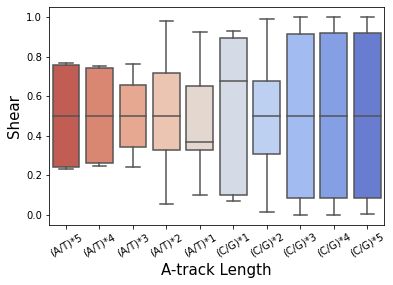

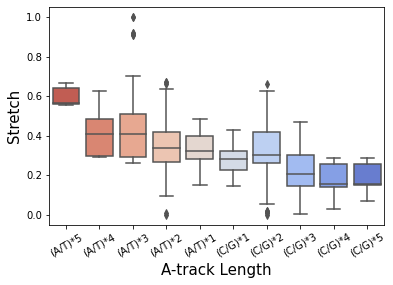

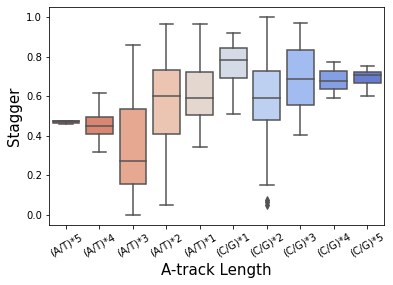

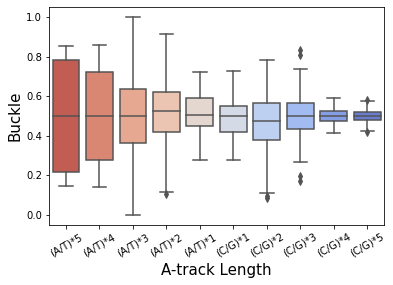

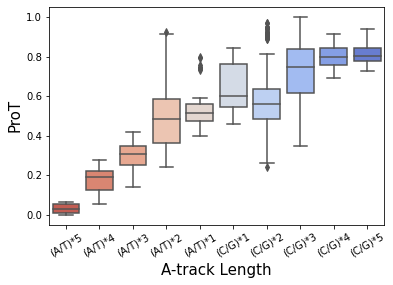

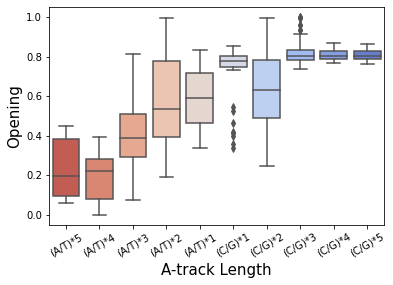

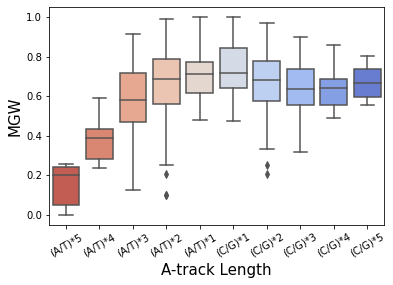

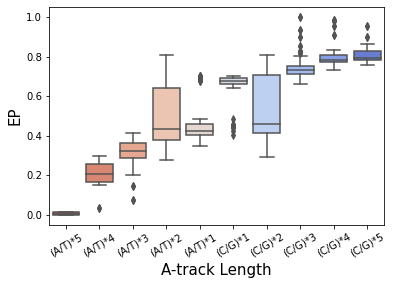

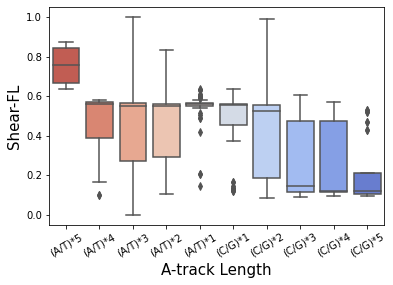

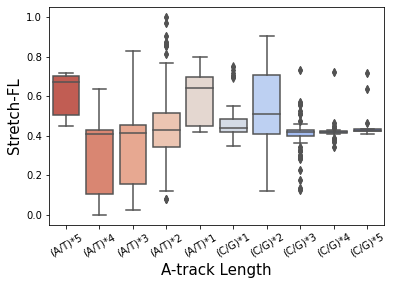

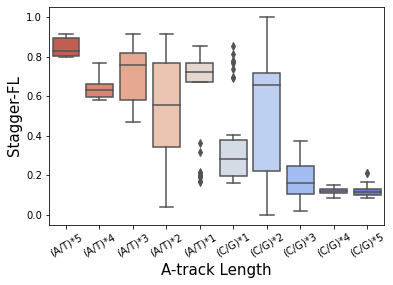

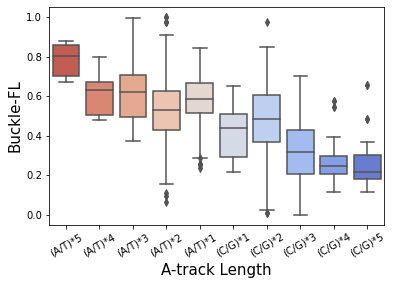

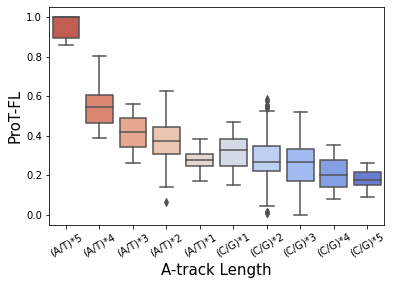

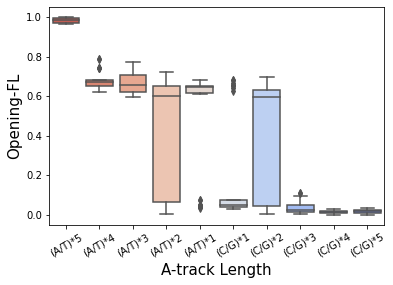

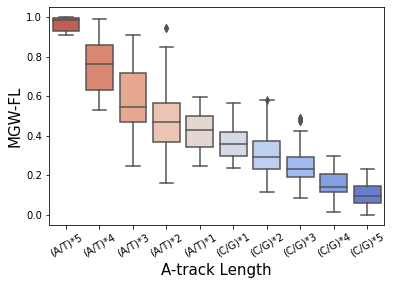

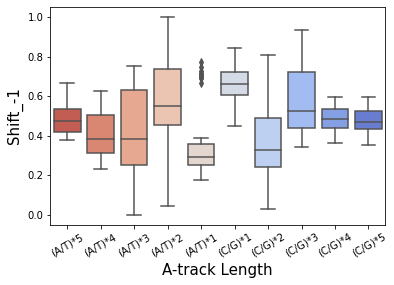

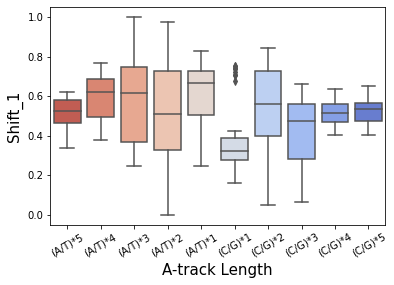

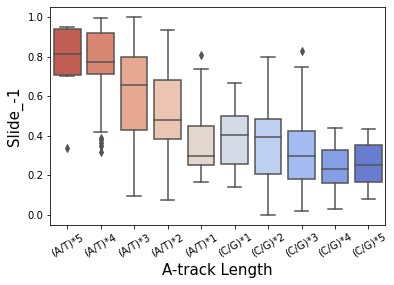

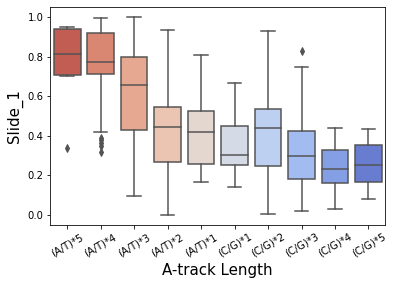

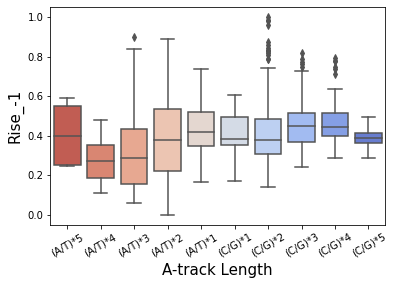

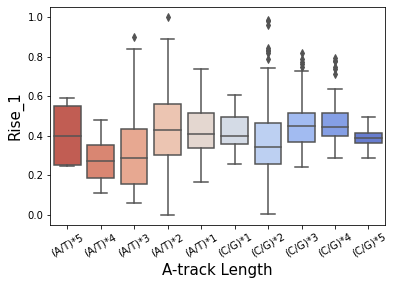

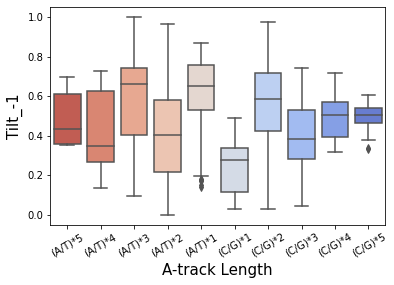

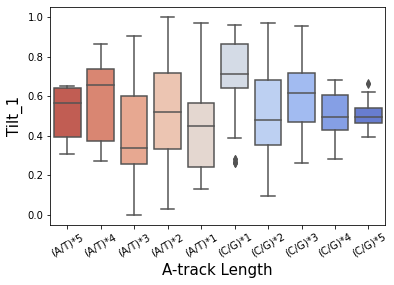

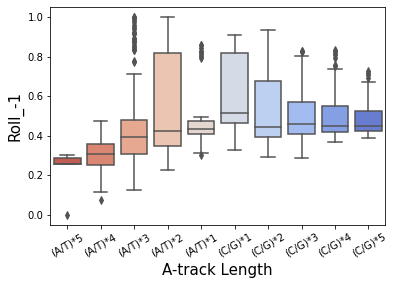

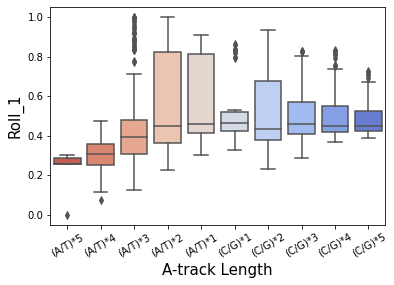

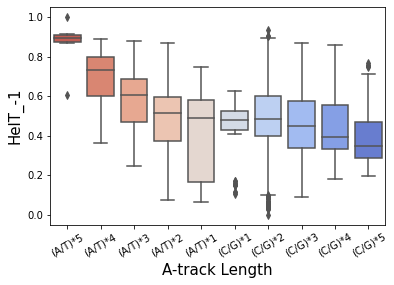

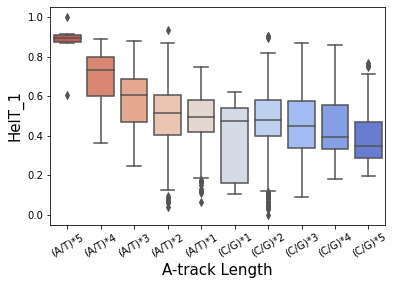

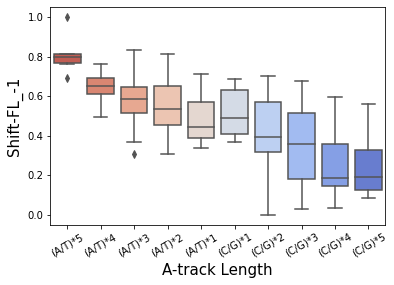

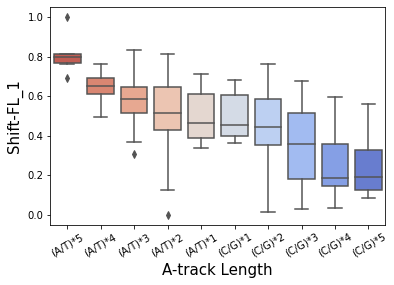

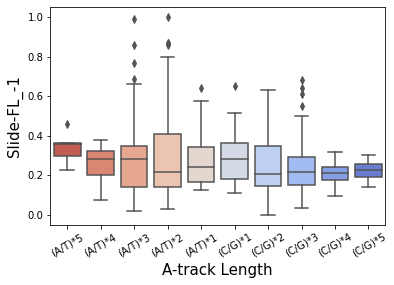

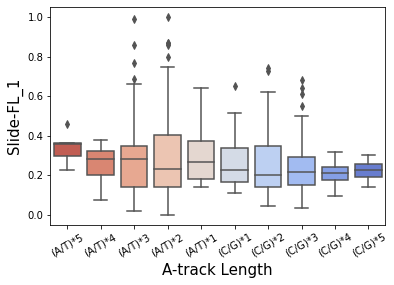

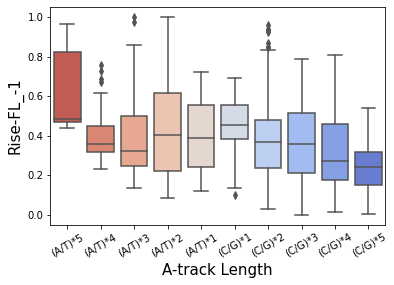

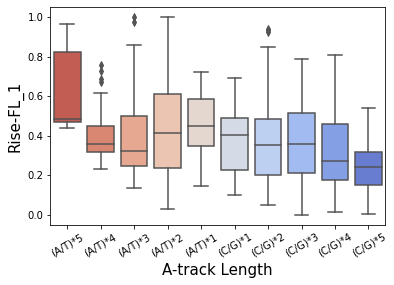

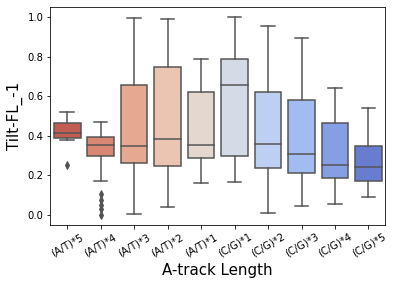

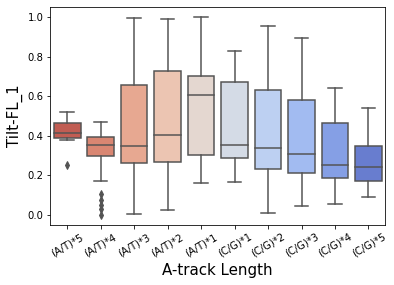

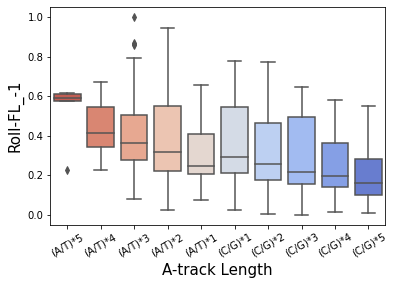

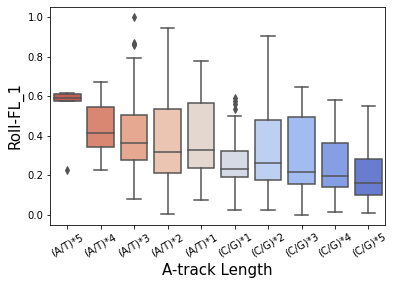

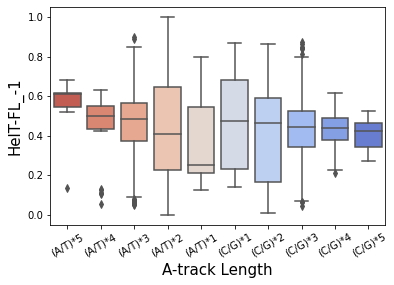

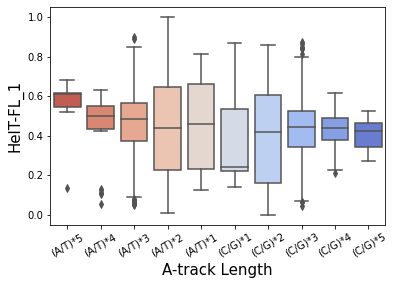

In [65]:
import seaborn as sns

for i in range(len(AllDNAshape)):
    plt.figure(i)
    ax = sns.boxplot(x="AtrackLength", y=AllDNAshape[i], data=norm_tb_df, palette='coolwarm_r',
                    order=['(A/T)*5','(A/T)*4','(A/T)*3','(A/T)*2','(A/T)*1',
                          '(C/G)*1','(C/G)*2','(C/G)*3','(C/G)*4','(C/G)*5'])
#     ax = sns.boxplot(x="AtrackLength", y=AllDNAshape[i], data=norm_tb_df, palette='YlOrRd_r',
#                     order=['(A/T)*5','(A/T)*4','(A/T)*3','(A/T)*2','(A/T)*1','(A/T)*0'])
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 30)
    ax.set_xlabel("A-track Length", fontsize = 15)
    ax.set_ylabel(ax.get_ylabel(), fontsize = 15)


<ipython-input-70-16ae321a401e>:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(i)


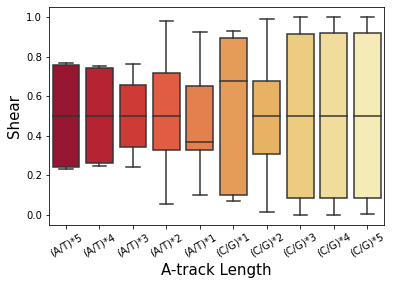

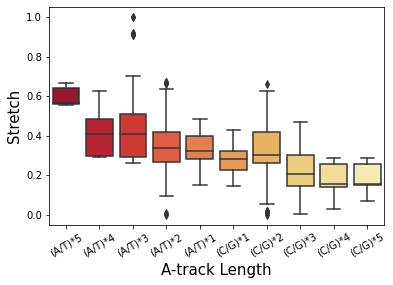

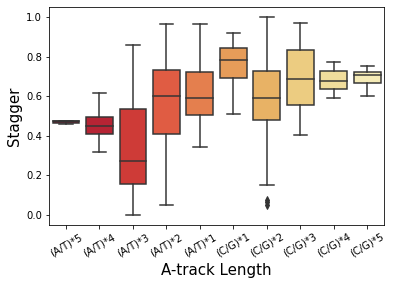

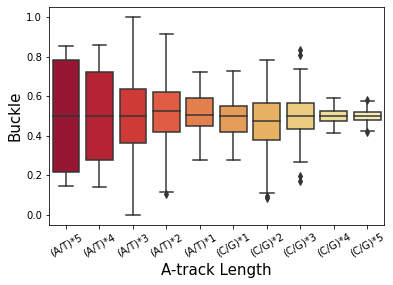

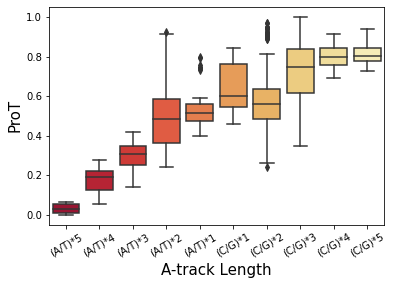

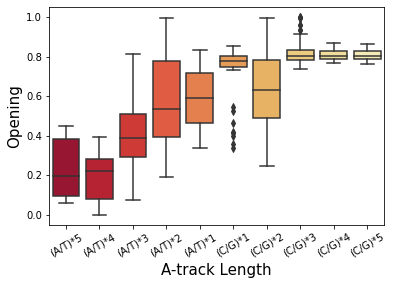

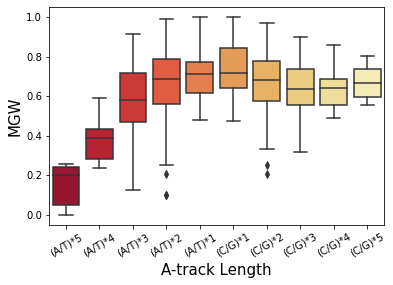

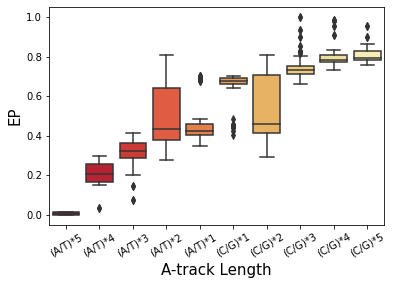

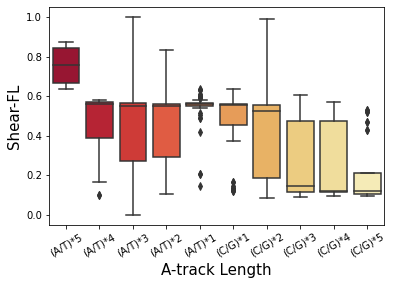

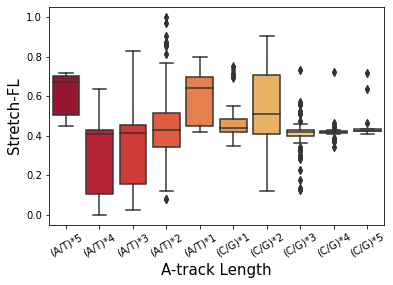

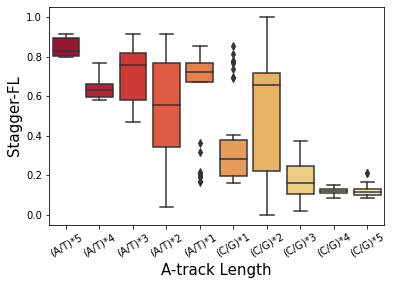

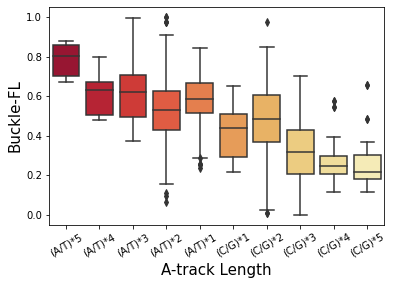

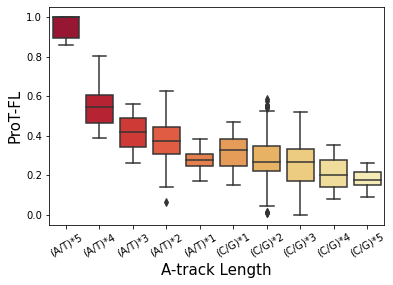

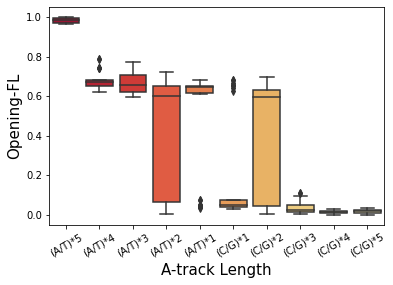

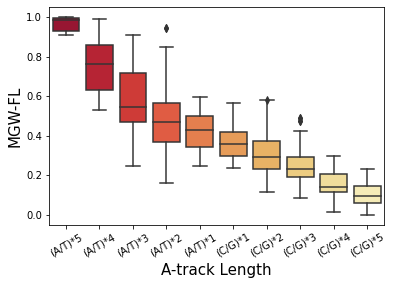

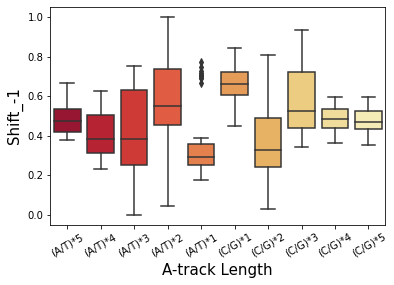

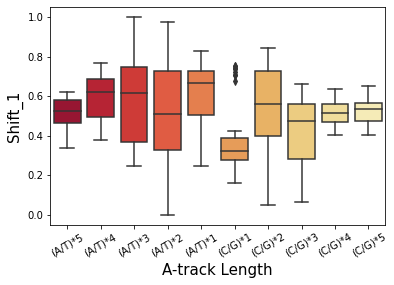

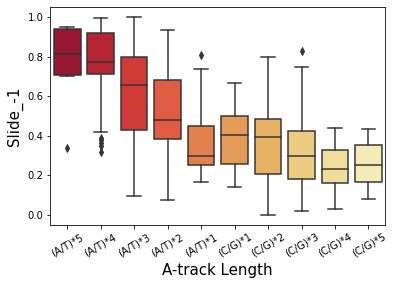

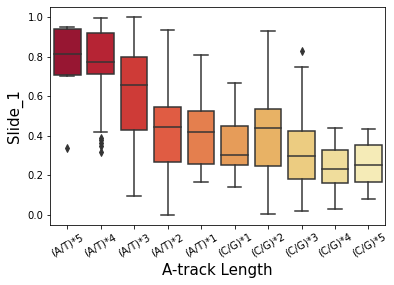

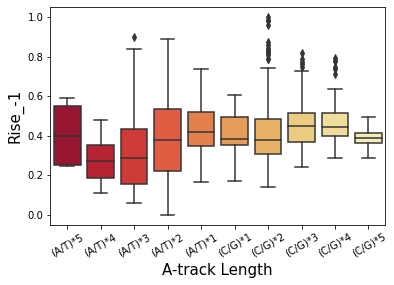

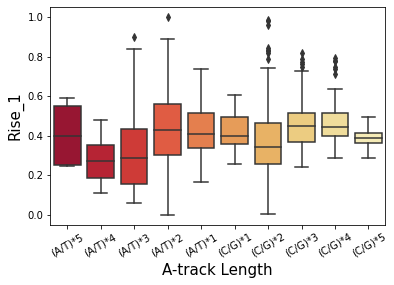

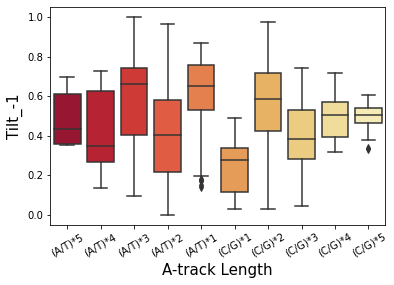

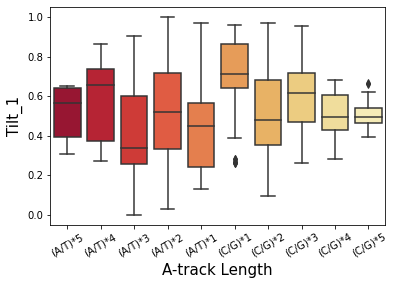

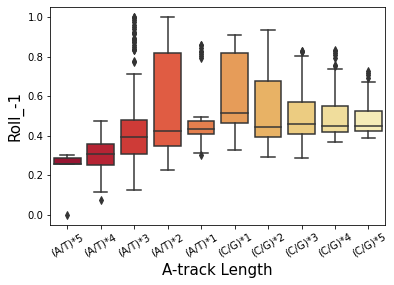

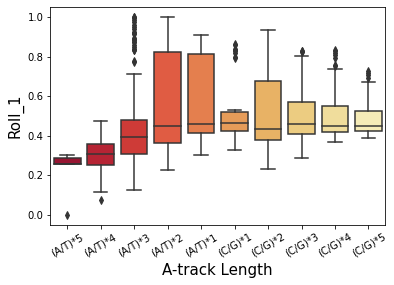

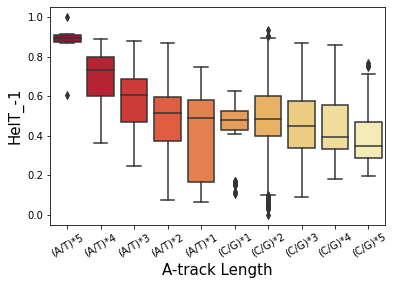

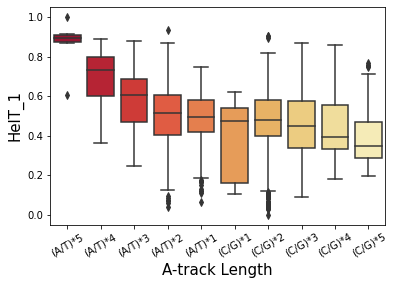

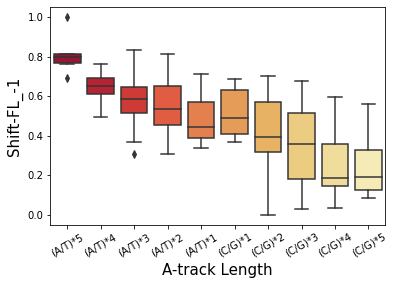

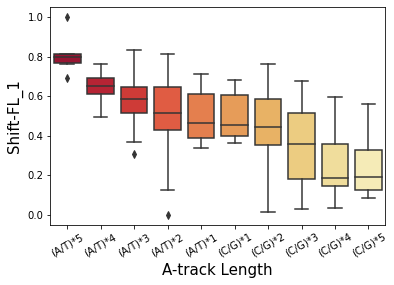

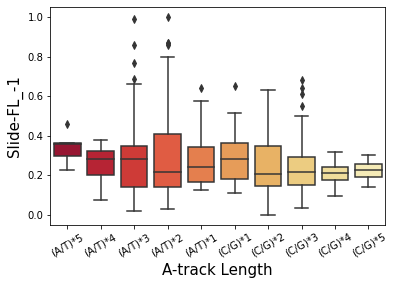

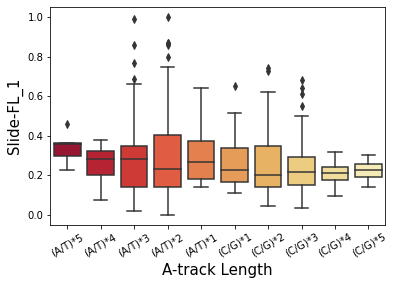

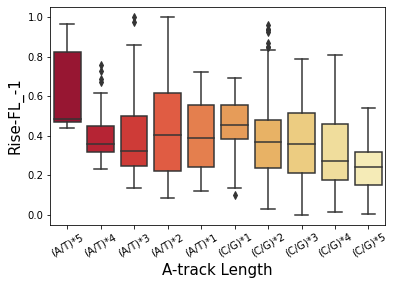

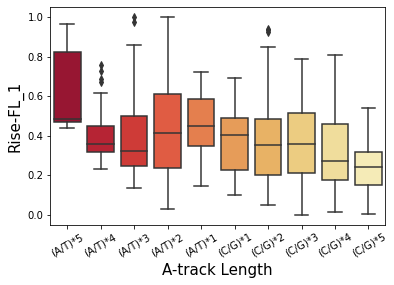

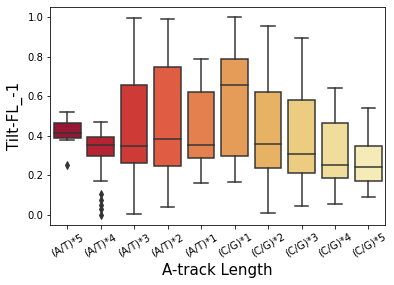

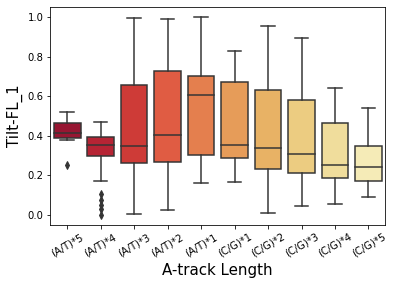

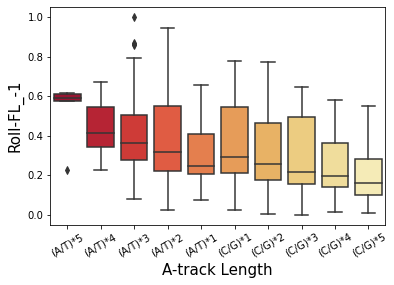

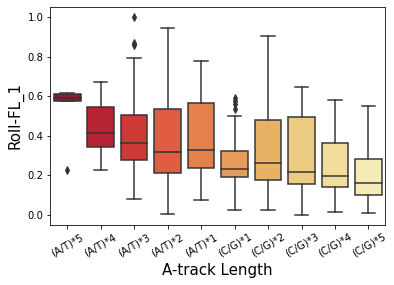

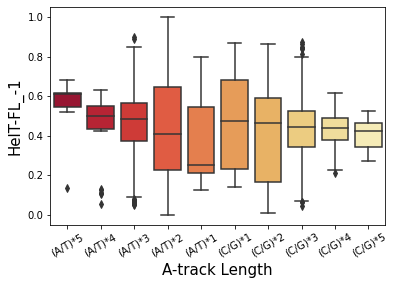

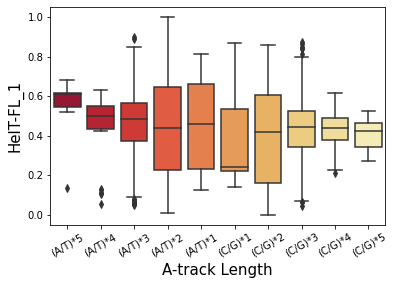

In [70]:
import seaborn as sns

for i in range(len(AllDNAshape)):
    plt.figure(i)
    ax = sns.boxplot(x="AtrackLength", y=AllDNAshape[i], data=norm_tb_df, palette='YlOrRd_r',
                    order=['(A/T)*5','(A/T)*4','(A/T)*3','(A/T)*2','(A/T)*1',
                          '(C/G)*1','(C/G)*2','(C/G)*3','(C/G)*4','(C/G)*5'])
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 30)
    ax.set_xlabel("A-track Length", fontsize = 15)
    ax.set_ylabel(ax.get_ylabel(), fontsize = 15)


In [68]:
all_norm_shape_vals

[[0.7249922094110315,
  0.9294172639451542,
  0.2742287316921159,
  0.6777812402617638,
  0.7125272670613899,
  0.6802742287316921,
  0.35384855095045187,
  0.6676534746026799,
  0.3197257712683079,
  0.084138360860081,
  0.6634465565596759,
  0.9214708631972577,
  0.6235587410408227,
  0.9007478965409785,
  0.7178248675599875,
  0.919445310065441,
  0.6547210969149267,
  0.32626986600186975,
  0.3312558429417264,
  0.3085073231536304,
  0.33748831411654723,
  0.675755687129947,
  0.88921782486756,
  0.6681209099407915,
  0.34901838578996575,
  0.9484263010283577,
  0.9171081333748831,
  0.8921782486755998,
  0.11826114054222502,
  0.3899968837644126,
  0.32221875973823627,
  0.2947958865690246,
  0.9141477095668432,
  0.26269866001869746,
  0.63773761296354,
  0.35758803365534436,
  0.6509816142100342,
  0.9707073854783421,
  0.05328762854471799,
  0.09364287940168282,
  0.9247429105640387,
  0.6017450919289498,
  0.9978186350888127,
  0.3457463384231848,
  0.8929573075724523,
  0.934

In [ ]:
#################################### DNA Shape values ####################################
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.spines 
from matplotlib.ticker import PercentFormatter
import  matplotlib.cm as cm
all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)


for i in range(len(All_params)):
# for i in range(2):
    pic_index = All_params[i]
    fig = plt.figure(figsize=(24,12))
    fig.suptitle(All_params_names[i], fontsize=16)
    total_plot_num = len(pic_index)
#     for j in range(2):
    for j in range(len(pic_index)):

        # Set up the plot
        ax = plt.subplot(2, 3, j+1)
    
        # Draw the plot
        x = all_norm_shape_vals[pic_index[j]]
        
        ############ Atrack plot
        cols = tbAtrackColor(tb)
        plt.scatter(tb.keys(), x, s=10, c=cols, cmap=cm.get_cmap('RdYlBu', 5))
        
        plt.tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False) # labels along the bottom edge are off
        plt.tick_params(
            axis='y',          # changes apply to the x-axis
            labelsize=15) # labels along the bottom edge are off
#         Title and labels
        ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 15)
#         ax.axvline(x='AAAAA', color='grey')
#         ax.axvline(x='CAAAA', color='grey')
#         ax.axvline(x='GAAAA', color='grey')
#         ax.axvline(x='TAAAA', color='grey')
#         [i.set_linewidth(1.5) for i in ax.spines.values()]
        
    plt.tight_layout()
    cbar = plt.colorbar()
#     cbar = fig.colorbar(ticks=range(1,1))
    ############ AT option
    cbar.ax.set_yticklabels(['(A/T)*5', '(A/T)*4', '(A/T)*3', '(A/T)*2', '(A/T)*1','(C/G)*1','(C/G)*2','(C/G)*3','(C/G)*4','(C/G)*5']) 

    ############ CG option
    plt.savefig(All_params_names[i]+"_scatter.jpg")
    plt.show()